<a href="https://colab.research.google.com/github/uday-andotra/WQU/blob/main/MScFE_610_FE_GWP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MScFE 610 - Financial Econometrics
Group Work Project 1

---



Group Members: Udayveer Singh Andotra, Deep Mer, Benjamin Nieves

Problem 1 - Omitted Variable Bias

True model: Y(i) = α + βx(i) + γw(i) + δz(i) + ε(i)
Misspecified model: Y(i) = α + βx(i) + γw(i) + μ(i)


---


1.d Simulation

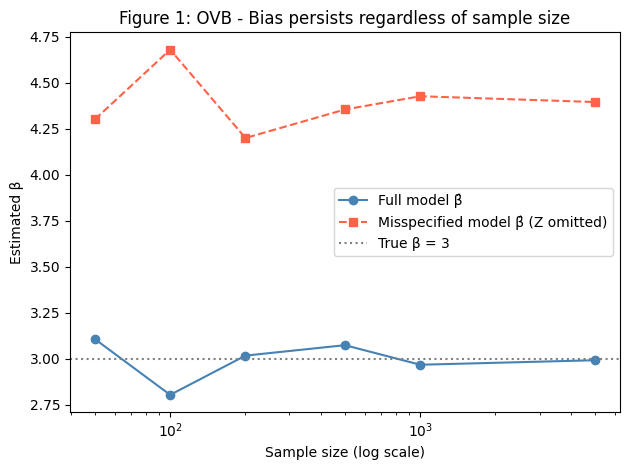

In [ ]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
# -------------------------------------------------------
# Figure 1 - OVB: Coefficient estimates comparison
# -------------------------------------------------------

sample_sizes = [50, 100, 200, 500, 1000, 5000]
beta_full_list, beta_mis_list = [], []

for n in sample_sizes:
    np.random.seed(42)
    X = np.random.normal(0, 1, n)
    W = np.random.normal(0, 1, n)
    Z = 0.7*X + 0.5*W + np.random.normal(0, 1, n)
    e = np.random.normal(0, 1, n)
    Y = 2 + 3*X + 1.5*W + 2*Z + e

    m_full = sm.OLS(Y, sm.add_constant(np.column_stack([X, W, Z]))).fit()
    m_mis  = sm.OLS(Y, sm.add_constant(np.column_stack([X, W]))).fit()

    beta_full_list.append(m_full.params[1])
    beta_mis_list.append(m_mis.params[1])

plt.plot(sample_sizes, beta_full_list, 'o-', color='steelblue', label='Full model β̂')
plt.plot(sample_sizes, beta_mis_list, 's--', color='tomato', label='Misspecified model β̂ (Z omitted)')
plt.axhline(3, color='gray', linestyle=':', label='True β = 3')
plt.xscale('log')
plt.xlabel('Sample size (log scale)')
plt.ylabel('Estimated β')
plt.title('Figure 1: OVB - Bias persists regardless of sample size')
plt.legend()
plt.tight_layout()
plt.savefig('figure1_ovb.png', dpi=150)
plt.show()

Problem 2 - Sensitivity to Outliers in OLS Regression

---

2.b Simulation

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# -------------------------------------------------------
# Problem 2b - Impact of Outliers on OLS Regression
# Simulation: clean data vs data with outliers
# -------------------------------------------------------

np.random.seed(42)
n = 100

# Generate clean dataset
X = np.random.uniform(0, 10, n)
e = np.random.normal(0, 1, n)
Y = 2 + 1.5 * X + e

# Add outliers
X_out = np.append(X, [2, 5, 8])
Y_out = np.append(Y, [25, 30, 5])

# Create DataFrames
data_clean = pd.DataFrame({'X': X, 'Y': Y})
data_out   = pd.DataFrame({'X': X_out, 'Y': Y_out})

# OLS models
ols_clean = smf.ols("Y ~ X", data=data_clean).fit()
ols_out   = smf.ols("Y ~ X", data=data_out).fit()

# Robust regression models (Huber and Bisquare - as in WQU M2L2)
rr_huber    = sm.RLM(data_out["Y"], sm.add_constant(data_out["X"]),
                     M=sm.robust.norms.HuberT()).fit()
rr_bisquare = sm.RLM(data_out["Y"], sm.add_constant(data_out["X"]),
                     M=sm.robust.norms.TukeyBiweight()).fit()

print("=== OLS Clean Data ===")
print(f"Intercept: {ols_clean.params[0]:.4f} | Slope: {ols_clean.params[1]:.4f}")
print("\n=== OLS With Outliers ===")
print(f"Intercept: {ols_out.params[0]:.4f} | Slope: {ols_out.params[1]:.4f}")
print("\n=== Robust - Huber ===")
print(f"Intercept: {rr_huber.params[0]:.4f} | Slope: {rr_huber.params[1]:.4f}")
print("\n=== Robust - Bisquare ===")
print(f"Intercept: {rr_bisquare.params[0]:.4f} | Slope: {rr_bisquare.params[1]:.4f}")

=== OLS Clean Data ===
Intercept: 2.2151 | Slope: 1.4540

=== OLS With Outliers ===
Intercept: 2.9271 | Slope: 1.3679

=== Robust - Huber ===
Intercept: 2.2431 | Slope: 1.4465

=== Robust - Bisquare ===
Intercept: 2.1978 | Slope: 1.4534


/tmp/ipykernel_2448/505479934.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Intercept: {ols_clean.params[0]:.4f} | Slope: {ols_clean.params[1]:.4f}")
/tmp/ipykernel_2448/505479934.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Intercept: {ols_out.params[0]:.4f} | Slope: {ols_out.params[1]:.4f}")
/tmp/ipykernel_2448/505479934.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Intercept: {rr_hube

/tmp/ipykernel_2448/3020872153.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(X_range, ols_clean.params[0]   + ols_clean.params[1]*X_range,
/tmp/ipykernel_2448/3020872153.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'b-',  linewidth=2, label=f'OLS clean (slope={ols_clean.params[1]:.3f})')
/tmp/ipykernel_2448/3020872153.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(X_range, ols_out.params[0]    

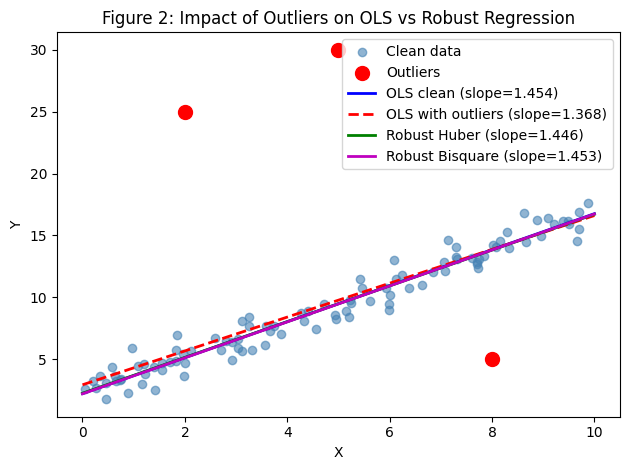

In [ ]:
# -------------------------------------------------------
# Figure 2 - Impact of outliers on regression lines
# -------------------------------------------------------

X_range = np.linspace(0, 10, 200)

plt.scatter(X, Y, color='steelblue', alpha=0.6, label='Clean data')
plt.scatter([2, 5, 8], [25, 30, 5], color='red', s=100, zorder=5, label='Outliers')

plt.plot(X_range, ols_clean.params[0]   + ols_clean.params[1]*X_range,
         'b-',  linewidth=2, label=f'OLS clean (slope={ols_clean.params[1]:.3f})')
plt.plot(X_range, ols_out.params[0]     + ols_out.params[1]*X_range,
         'r--', linewidth=2, label=f'OLS with outliers (slope={ols_out.params[1]:.3f})')
plt.plot(X_range, rr_huber.params[0]    + rr_huber.params[1]*X_range,
         'g-',  linewidth=2, label=f'Robust Huber (slope={rr_huber.params[1]:.3f})')
plt.plot(X_range, rr_bisquare.params[0] + rr_bisquare.params[1]*X_range,
         'm-',  linewidth=2, label=f'Robust Bisquare (slope={rr_bisquare.params[1]:.3f})')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Figure 2: Impact of Outliers on OLS vs Robust Regression')
plt.legend()
plt.tight_layout()
plt.savefig('figure2_outliers.png', dpi=150)
plt.show()


Problem 3

---


Analysis of the Best Regression Model


In [ ]:
import pandas as pd
import statsmodels.api as sm
import itertools

# 1. Load the dataset (Make sure the file is in your folder)
# Replace with the correct path if necessary
df = pd.read_csv('/FE-GWP1_model_selection_2.csv')

In [ ]:
# 2. Define target and potential predictors based on your column names
y = df['Y']
candidates = ['Z1 ', 'Z2', 'Z3', 'Z4', 'Z5']

best_aic_model = None
best_aic_score = float('inf')
best_bic_model = None
best_bic_score = float('inf')
best_r2_model = None
best_r2_score = -float('inf')

print("Running Model Selection with predictors: ", candidates)

Running Model Selection with predictors:  ['Z1 ', 'Z2', 'Z3', 'Z4', 'Z5']


In [ ]:
# 3. Loop through all possible combinations of variables
for k in range(1, len(candidates) + 1):
    for subset in itertools.combinations(candidates, k):
        # Create the X matrix for this subset
        features = list(subset)
        X = df[features]
        X = sm.add_constant(X) # Add intercept

        # Fit model
        model = sm.OLS(y, X).fit()

        # Check AIC (Lower is better)
        if model.aic < best_aic_score:
            best_aic_score = model.aic
            best_aic_model = features

        # Check BIC (Lower is better)
        if model.bic < best_bic_score:
            best_bic_score = model.bic
            best_bic_model = features

        # Check Adjusted R-squared (Higher is better)
        if model.rsquared_adj > best_r2_score:
            best_r2_score = model.rsquared_adj
            best_r2_model = features

In [ ]:
# 4. Print Results
print("\n--- RESULTS ---")
print(f"Best Model by AIC: {best_aic_model} (AIC: {best_aic_score:.4f})")
print(f"Best Model by BIC: {best_bic_model} (BIC: {best_bic_score:.4f})")
print(f"Best Model by Adj R2: {best_r2_model} (Adj R2: {best_r2_score:.4f})")


--- RESULTS ---
Best Model by AIC: ['Z1 ', 'Z2', 'Z3', 'Z4', 'Z5'] (AIC: -165.9022)
Best Model by BIC: ['Z1 ', 'Z2', 'Z3', 'Z4', 'Z5'] (BIC: -150.2712)
Best Model by Adj R2: ['Z1 ', 'Z2', 'Z3', 'Z4', 'Z5'] (Adj R2: 0.9936)


In [ ]:
# 5. Summary of the Best Model
print("\n--- Summary of Best Model (AIC Winner) ---")
X_best = sm.add_constant(df[list(best_aic_model)])
final_model = sm.OLS(y, X_best).fit()
print(final_model.summary())


--- Summary of Best Model (AIC Winner) ---
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     3062.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          2.07e-102
Time:                        17:30:38   Log-Likelihood:                 88.951
No. Observations:                 100   AIC:                            -165.9
Df Residuals:                      94   BIC:                            -150.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const   

Problem 5

---


5.b Use real economic data for equities and illustrate if the time series you chose has a unit root.

5.c Economics and Finance we are concerned about a unit root
and not, say a root of 1.5? Simulations to understand what the time
series would look like in the two cases.

In [ ]:
!pip install yfinance pandas statsmodels matplotlib numpy

✅ Downloaded 6,602 observations
Date range: 2000-01-03 to 2026-04-02

Running Augmented Dickey-Fuller tests...

=== ADF Test on LEVELS (prices) ===
Test statistic : 2.6972
p-value        : 0.9991
Critical values: {'1%': np.float64(-3.431345261770753), '5%': np.float64(-2.861979821250125), '10%': np.float64(-2.567004113396368)}

=== ADF Test on LOG prices ===
Test statistic : 0.8791
p-value        : 0.9928

=== ADF Test on DAILY RETURNS ===
Test statistic : -20.5764
p-value        : 0.0000


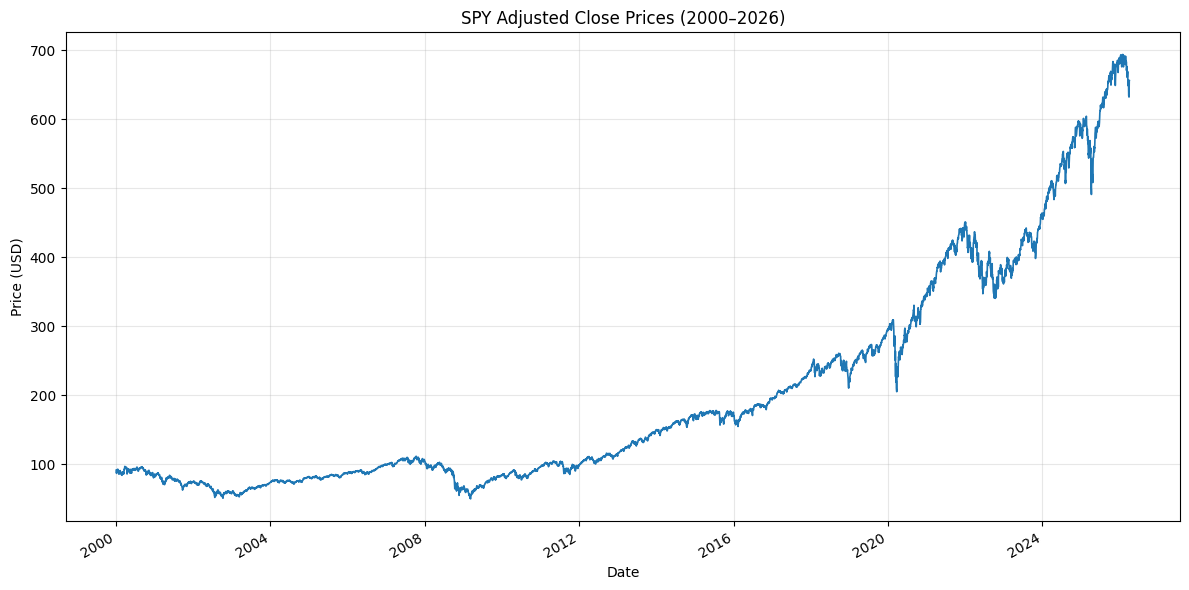

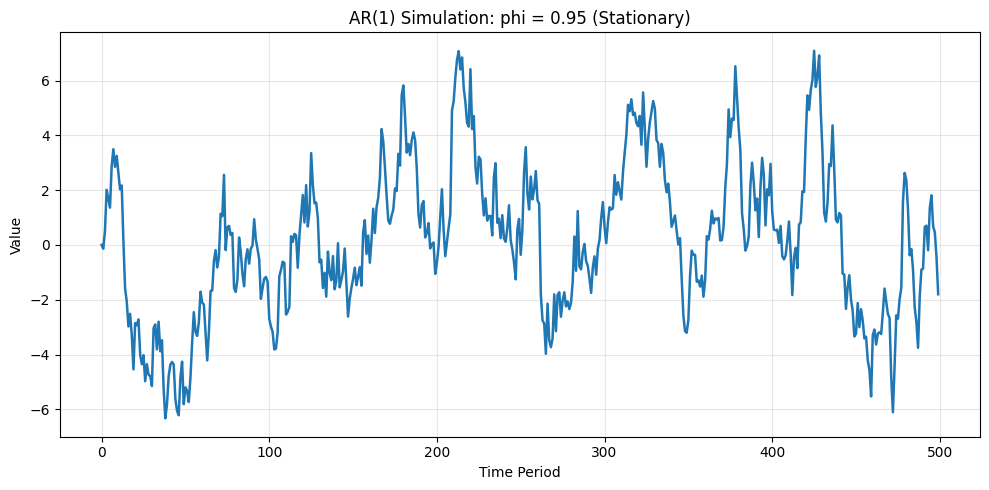

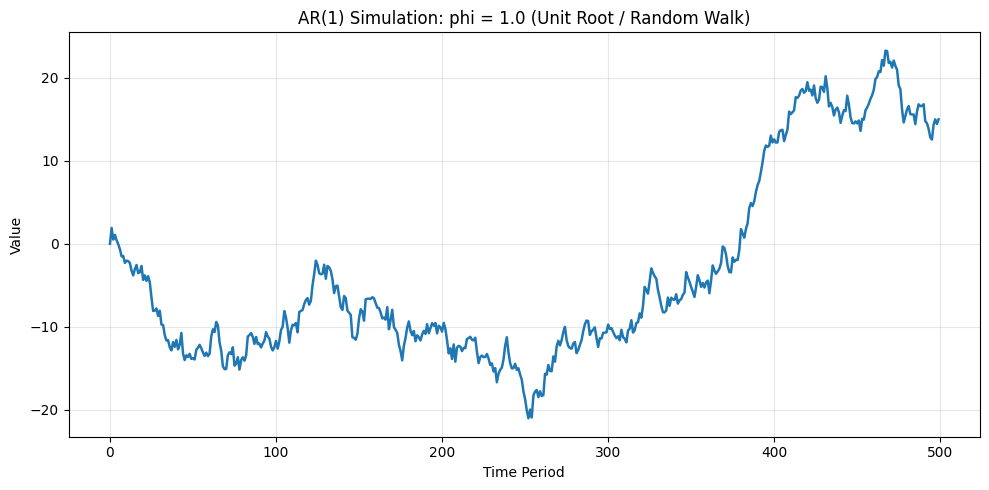

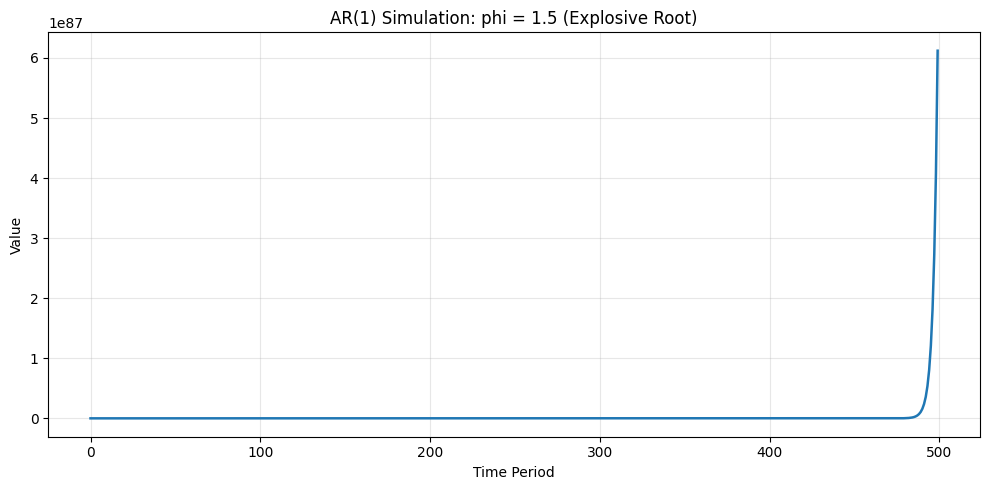


✅ All plots generated successfully!
   • SPY price chart
   • Three AR(1) simulations (stationary, unit root, explosive)


In [ ]:
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np

# ==================== SETTINGS ====================
np.random.seed(42)          # for reproducible simulations
n_sim = 500                 # length of each AR(1) simulation
sigma = 1.0                 # innovation standard deviation

# ==================== 1. FETCH REAL SPY DATA ====================
print("Downloading SPY adjusted close prices...")
ticker = yf.Ticker("SPY")
spy = ticker.history(start="2000-01-01", end="2026-04-07")["Close"]

print(f"✅ Downloaded {len(spy):,} observations")
print(f"Date range: {spy.index[0].date()} to {spy.index[-1].date()}\n")

# ==================== 2. ADF TESTS ====================
print("Running Augmented Dickey-Fuller tests...")

# Levels (raw prices)
adf_levels = adfuller(spy, regression="c", autolag="AIC")
print("\n=== ADF Test on LEVELS (prices) ===")
print(f"Test statistic : {adf_levels[0]:.4f}")
print(f"p-value        : {adf_levels[1]:.4f}")
print(f"Critical values: {adf_levels[4]}")

# Log prices
adf_log = adfuller(np.log(spy), regression="c", autolag="AIC")
print("\n=== ADF Test on LOG prices ===")
print(f"Test statistic : {adf_log[0]:.4f}")
print(f"p-value        : {adf_log[1]:.4f}")

# Daily returns
returns = 100 * spy.pct_change().dropna()
adf_ret = adfuller(returns, regression="c", autolag="AIC")
print("\n=== ADF Test on DAILY RETURNS ===")
print(f"Test statistic : {adf_ret[0]:.4f}")
print(f"p-value        : {adf_ret[1]:.4f}")

# ==================== 3. PLOT REAL SPY PRICE SERIES ====================
plt.figure(figsize=(12, 6))
spy.plot(color="tab:blue", linewidth=1.2)
plt.title("SPY Adjusted Close Prices (2000–2026)")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== 4. AR(1) SIMULATIONS ====================
def simulate_ar1(phi, n=n_sim, sigma=sigma):
    eps = np.random.normal(0, sigma, n)
    y = np.zeros(n)
    y[0] = 0.0
    for t in range(1, n):
        y[t] = phi * y[t-1] + eps[t]
    return y

# Generate the three series
y_stat = simulate_ar1(0.95)
y_unit = simulate_ar1(1.00)
y_expl = simulate_ar1(1.50)

# Plot stationary (phi = 0.95)
plt.figure(figsize=(10, 5))
plt.plot(y_stat, color="tab:blue", linewidth=1.8)
plt.title("AR(1) Simulation: phi = 0.95 (Stationary)")
plt.xlabel("Time Period")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot unit root (phi = 1.0)
plt.figure(figsize=(10, 5))
plt.plot(y_unit, color="tab:blue", linewidth=1.8)
plt.title("AR(1) Simulation: phi = 1.0 (Unit Root / Random Walk)")
plt.xlabel("Time Period")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot explosive (phi = 1.5)
plt.figure(figsize=(10, 5))
plt.plot(y_expl, color="tab:blue", linewidth=1.8)
plt.title("AR(1) Simulation: phi = 1.5 (Explosive Root)")
plt.xlabel("Time Period")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ All plots generated successfully!")
print("   • SPY price chart")
print("   • Three AR(1) simulations (stationary, unit root, explosive)")